# Tensors:


## Basic tensors:

In [1]:
import torch

a = torch.rand(2, 3)
b = torch.rand(2, 3)
print(a)

print(a)

tensor([[0.3106, 0.6888, 0.6498],
        [0.2129, 0.1447, 0.4918]])
tensor([[0.3106, 0.6888, 0.6498],
        [0.2129, 0.1447, 0.4918]])


In [ ]:
add = a + b
sub = a - b
mul = a * b

print(add)
print(sub)
print(mul)

tensor([[0.4759, 1.0870, 0.7358],
        [0.3045, 0.3422, 1.2086]])
tensor([[ 0.1453,  0.2907,  0.5639],
        [ 0.1212, -0.0529, -0.2251]])
tensor([[0.0513, 0.2743, 0.0559],
        [0.0195, 0.0286, 0.3525]])


## Transpose:


In [3]:
a = torch.rand(2, 3)
c = b @ a.T
print(c)

tensor([[0.3494, 0.2252],
        [0.1964, 0.7590]])


## Broadcasting:

In [ ]:
# simple
a = torch.tensor([[1], [2], [3]])
b = torch.tensor([4, 5, 6])
print(a + b)

# batch:
batch_size = 10
a = torch.rand(batch_size, 3, 4)
b = torch.rand(batch_size,4, 5)
c = torch.rand(4, 5)

a_mul_b = a @ b
print(a_mul_b.shape)
a_mul_c = a @ c
print(a_mul_c.shape)


tensor([[5, 6, 7],
        [6, 7, 8],
        [7, 8, 9]])
torch.Size([10, 3, 5])
torch.Size([10, 3, 5])


## Tensor Reshape:

In [ ]:
import torch

a = torch.rand(size = (2, 3, 4))
print(a.shape)

a_flat = a.reshape(-1)
print(a_flat.shape)

torch.Size([2, 3, 4])
torch.Size([24])


In [4]:
a_transpose_1 = a.transpose(1, 0)
a_transpose_2 = a.transpose(1, 2)
print(a_transpose_1.shape)
print(a_transpose_2.shape)



torch.Size([3, 2, 4])
torch.Size([2, 4, 3])


In [7]:
a_perm = a.permute([1, 2, 0])
print(a_perm.shape)

torch.Size([3, 4, 2])


In [9]:
a_1 = a.reshape(6, -1)
a_2 = a.reshape(8, -1)
print(a_1.shape)
print(a_2.shape)

torch.Size([6, 4])
torch.Size([8, 3])


## Expanding(unsquezing) and Squeezing:

In [14]:
a_expanded = a.unsqueeze(1)
a_squeezed = a_expanded.squeeze(1)
print(a_expanded.shape)
print(a_squeezed.shape)


torch.Size([2, 1, 3, 4])
torch.Size([2, 3, 4])


## Basic autograd with scalar values

In [19]:
import torch

x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = x**2 + y**3
print(z)


tensor(31., grad_fn=<AddBackward0>)


In [20]:
z.backward()
dz_dx = x.grad
dz_dy = y.grad
print(f"dz/dx = [green]{dz_dx}[/green]")
print(f"dz/dy = [green]{dz_dy}[/green]")

dz/dx = [green]4.0[/green]
dz/dy = [green]27.0[/green]


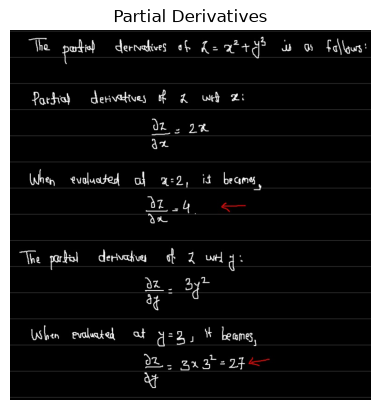

In [7]:
# Display a warning if the image 'partial_derivatives.png' is missing
import os
from PIL import Image
import matplotlib.pyplot as plt

img_path = 'images/partial_derivatives.jpeg'

if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title('Partial Derivatives')
    plt.show()
else:
    print(f"Warning: Image file '{img_path}' not found. Skipping image display.")

## Chain rule:  

In [12]:
import torch

x = torch.tensor(2.0, requires_grad = True)
y = x**2
z = y+1
w = z**2

dw_dz = torch.autograd.grad(outputs = w, inputs = z, retain_graph = True)[0]
dz_dy = torch.autograd.grad(outputs = z, inputs = y, retain_graph = True)[0]
dy_dx = torch.autograd.grad(outputs = y, inputs = x, retain_graph = True)[0]

print(f"dw_dz: {dw_dz}")
print(f"dz_dy: {dz_dy}")
print(f"dy_dx: {dy_dx}")

dw_dz: 10.0
dz_dy: 1.0
dy_dx: 4.0


In [13]:
dw_dx = dw_dz*dz_dy*dy_dx
print(dw_dx)

tensor(40.)


In [15]:
w.backward()
print(x.grad)

tensor(40.)


In [17]:
# backward propagation on vector:
import torch

x = torch.tensor([-1.0, 2.0, 1.0], requires_grad = True)
y = x**2
z = y+1
w = z**2

w.sum().backward()
print(x.grad)

tensor([-8., 40.,  8.])


## Gradient Accumulation:

In [21]:
x = torch.tensor(1.0, requires_grad = True)
y1 = x**2
y1.backward()
print(x.grad)
y2 = x**3
y2.backward()
print(x.grad)


tensor(2.)
tensor(5.)


In [22]:
x = torch.tensor(1.0, requires_grad = True)
y1 = x**2
y1.backward()
print(x.grad)

x.grad.zero_()
print(x.grad)


y2 = x**3
y2.backward()
print(x.grad)


tensor(2.)
tensor(0.)
tensor(3.)


## Vector Autograd:

In [23]:
import torch

x = torch.tensor([1.0, 2.0, 3.0], requires_grad = True)
y = torch.tensor([3.0, 5.0, 6.0], requires_grad = True)

z0 = x**2 + y**3
z = z0.sum()
print(z0)
print(z)


tensor([ 28., 129., 225.], grad_fn=<AddBackward0>)
tensor(382., grad_fn=<SumBackward0>)


In [24]:
z.backward()

dz_dx = x.grad
dz_dy = y.grad
print(x.grad)
print(y.grad)



tensor([2., 4., 6.])
tensor([ 27.,  75., 108.])


## Unexpected functios pytorch can flow gradients through:

In [61]:
import torch.nn.functional as F

a = torch.tensor([1.0, 3.4, -2.9], requires_grad = True)
b = torch.tensor([10.0, 2.4, 1.2], requires_grad = True)

ans = torch.max(a, b)
print(f"max, ans={ans}")
ans = torch.where(a+b<3.0, a, b)
print(f"where, ans={ans}")
ans = torch.clamp(a, 1.0, 2.0)
print(f"clamp, ans={ans}")
ans = torch.abs(a)
print(f"abs, ans={ans}")
# ans = F.relu(x)
ans = torch.relu(a)
print(f"relu, ans={ans}")


max, ans=tensor([10.0000,  3.4000,  1.2000], grad_fn=<MaximumBackward0>)
where, ans=tensor([10.0000,  2.4000, -2.9000], grad_fn=<WhereBackward0>)
clamp, ans=tensor([1., 2., 1.], grad_fn=<ClampBackward1>)
abs, ans=tensor([1.0000, 3.4000, 2.9000], grad_fn=<AbsBackward0>)
relu, ans=tensor([1.0000, 3.4000, 0.0000], grad_fn=<ReluBackward0>)


In [62]:
ans = torch.round(a)
print(f"round, ans={ans}")
ans = torch.sign(a)
print(f"sign, ans={ans}")

# Step function
input = torch.tensor(-1.0)
ans = torch.heaviside(input, a)
print(f"heaviside, ans={ans}")

input = torch.tensor(0.0)
ans = torch.heaviside(input, a)
print(f"heaviside, ans={ans}")

input = torch.tensor(1.0)
ans = torch.heaviside(input, a)
print(f"heaviside, ans={ans}")



round, ans=tensor([ 1.,  3., -3.], grad_fn=<RoundBackward0>)
sign, ans=tensor([ 1.,  1., -1.], grad_fn=<SignBackward0>)
heaviside, ans=tensor([0., 0., 0.], grad_fn=<NotImplemented>)
heaviside, ans=tensor([ 1.0000,  3.4000, -2.9000], grad_fn=<NotImplemented>)
heaviside, ans=tensor([1., 1., 1.], grad_fn=<NotImplemented>)


In [63]:
ans = torch.topk(a, 2)
# print(ans)
for val in ans:
    print(val)

tensor([3.4000, 1.0000], grad_fn=<TopkBackward0>)
tensor([1, 0])


#### max function example:

In [65]:
import torch
a = torch.tensor([1.0, 3.4, -2.9], requires_grad = True)
b = torch.tensor([10.0, 2.4, 1.2], requires_grad = True)

z = torch.max(a, b)
loss = z.sum()
loss.backward()
print(x.grad)
print(y.grad)
print(loss)

tensor([2., 4., 6.])
tensor([ 27.,  75., 108.])
tensor(14.6000, grad_fn=<SumBackward0>)


## Linear models and MLP:

In [103]:
import pandas as pd
from sklearn.preprocessing import normalize

In [104]:

df = pd.DataFrame({
    'area': [120, 180, 150, 210, 105],
    "age": [5, 2, 1, 2, 1],
    "price": [30, 90, 100, 180, 85]
})

print(df.to_string())

   area  age  price
0   120    5     30
1   180    2     90
2   150    1    100
3   210    2    180
4   105    1     85


In [119]:
df = normalize(df)
print(df)


[[0.96935087 0.04038962 0.24233772]
 [0.89438303 0.00993759 0.44719151]
 [0.83203749 0.00554692 0.55469166]
 [0.75923675 0.00723083 0.65077436]
 [0.77722358 0.00740213 0.62918099]]


In [120]:
X = torch.tensor(df[:, :2], dtype=torch.float32)
Y = torch.tensor(df[:, 2:], dtype=torch.float32)
print(X)
print(Y)


tensor([[0.9694, 0.0404],
        [0.8944, 0.0099],
        [0.8320, 0.0055],
        [0.7592, 0.0072],
        [0.7772, 0.0074]])
tensor([[0.2423],
        [0.4472],
        [0.5547],
        [0.6508],
        [0.6292]])


In [121]:
W = torch.rand(size = (2, 1), requires_grad = True)
B = torch.rand(1, requires_grad = True)

# print(stringify_WB(W, B))



In [122]:
pred = X@W + B
error = (Y-pred)**2
loss = error.mean()
old_loss = loss
# print(get_error_df(Y, pred, error))
# print(loss.items())

In [123]:
loss.backward()

dW = W.grad
dB = B.grad
# print(stringify_grads(W, B, dW, dB))


In [124]:
lr = 0.2
with torch.no_grad():
    W = W - lr*dW
    B = B - lr*dB

print(W, B)

tensor([[0.2322],
        [0.4948]]) tensor([0.2537])


In [125]:
pred = X@W + B
new_loss = ((Y - pred)**2).mean()
print("old_loss", old_loss)
print("new_loss", new_loss)



old_loss tensor(0.0479, grad_fn=<MeanBackward0>)
new_loss tensor(0.0322)


### FULL training (single layer):

In [136]:
from torch.optim import SGD

# Initialize the weights and bias
W = torch.rand(size=(2, 1), requires_grad = True)
B = torch.rand(1, requires_grad = True)

# initialize the optimizer
optimizer = SGD(params = (W, B), lr = 0.1)

for step in range(10):
    pred = X@W + B # Forward pass
    loss = ((Y - pred)**2).mean() # Calculate loss
    loss.backward() # Calculate the gradients
    optimizer.step() # Update W and B
    optimizer.zero_grad() # Reset all gradeints
    print(f"Step: {step}, Loss: {loss.item():.4f}")


Step: 0, Loss: 0.0407
Step: 1, Loss: 0.0392
Step: 2, Loss: 0.0386
Step: 3, Loss: 0.0383
Step: 4, Loss: 0.0381
Step: 5, Loss: 0.0380
Step: 6, Loss: 0.0379
Step: 7, Loss: 0.0379
Step: 8, Loss: 0.0378
Step: 9, Loss: 0.0377


In [137]:
final_new_loss = ((Y - pred)**2).mean()
print(final_new_loss)

tensor(0.0377, grad_fn=<MeanBackward0>)


## MLP training:

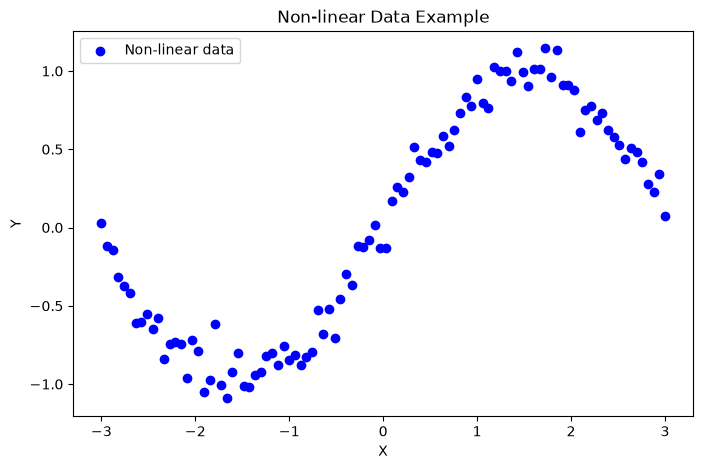

In [144]:
import torch
import matplotlib.pyplot as plt

# Generate some non-linear data
X = torch.unsqueeze(torch.linspace(-3, 3, 100), dim=1)
Y = torch.sin(X) + 0.1 * torch.randn(X.size())  # Example non-linear data

# Plot it
plt.figure(figsize=(8, 5))
plt.scatter(X.numpy(), Y.numpy(), color='b', label='Non-linear data')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Non-linear Data Example')
plt.legend()
plt.show()

In [145]:
from torch import nn
from torch.nn import Sequential, MSELoss

hidden_dim = 128
model = Sequential(
    nn.Linear(in_features = 1, out_features = hidden_dim),
    nn.ReLU(),
    nn.Linear(in_features = hidden_dim, out_features = hidden_dim),
    nn.ReLU(),
    nn.Linear(in_features = hidden_dim, out_features = 1),
)
print(model)


Sequential(
  (0): Linear(in_features=1, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=1, bias=True)
)


In [148]:
# some non linear data
from torch.optim import SGD

optimizer = SGD(model.parameters(), lr=0.1)
loss_criterion = nn.MSELoss()

model.train()
for i in range(200):
    pred = model(X)
    
    loss = loss_criterion(pred, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%20==0:
        print(f"Step = {i}, loss = {loss.item():.3f}")


Step = 0, loss = 0.665
Step = 20, loss = 0.062
Step = 40, loss = 0.043
Step = 60, loss = 0.069
Step = 80, loss = 0.064
Step = 100, loss = 0.058
Step = 120, loss = 0.054
Step = 140, loss = 0.051
Step = 160, loss = 0.048
Step = 180, loss = 0.045


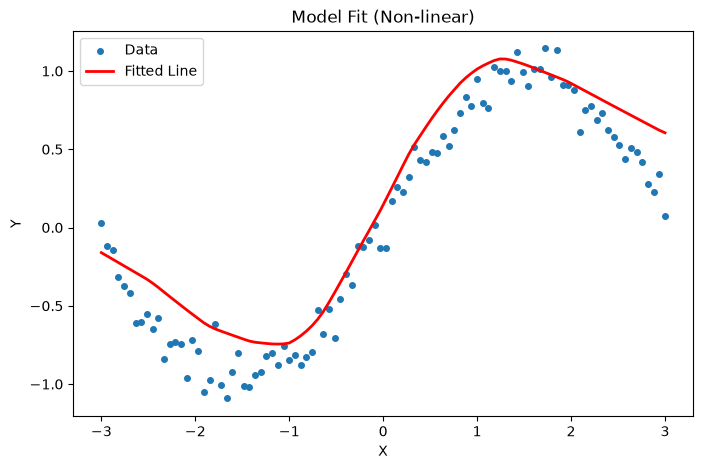

In [149]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    pred_Y = model(X)

plt.figure(figsize=(8,5))
plt.scatter(X.numpy(), Y.numpy(), label='Data', s=16)
plt.plot(X.numpy(), pred_Y.numpy(), c='r', label='Fitted Line', linewidth=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Model Fit (Non-linear)')
plt.legend()
plt.show()